In [1]:
# Develop an LSTM-based model for time-series forecasting using stock price, weather, or sales datasets.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.0 MB/s eta 0:00:00


In [5]:
# Install yfinance
!pip install yfinance -q

In [11]:
# Load AAPL stock data directly
import pandas as pd

url = "https://raw.githubusercontent.com/kristoffer-paulsson/stock-data/master/aapl.csv"

data = pd.read_csv(url, sep=";")

data["date"] = pd.to_datetime(data["date"])

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (9400, 6)


,date,open,high,low,close,volume
0,1980-12-12,28.75,28.87,28.75,28.75,2093900.0
1,1980-12-15,27.38,27.38,27.25,27.25,785200.0
2,1980-12-16,25.37,25.37,25.25,25.25,472000.0
3,1980-12-17,25.87,26.00,25.87,25.87,385900.0
4,1980-12-18,26.63,26.75,26.63,26.63,327900.0


In [12]:
# Check the dataset
print(data.shape)
print(data.columns)
data.tail()

(9400, 6)
Index(['date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')


,date,open,high,low,close,volume
9395,2018-03-21,175.04,175.09,171.26,171.270,35247360.0
9396,2018-03-22,170.00,172.68,168.60,168.845,41051076.0
9397,2018-03-23,168.39,169.92,164.94,164.940,40248952.0
9398,2018-03-26,168.07,173.10,166.44,172.770,36272616.0
9399,2018-03-27,173.68,175.15,166.92,168.340,38962840.0


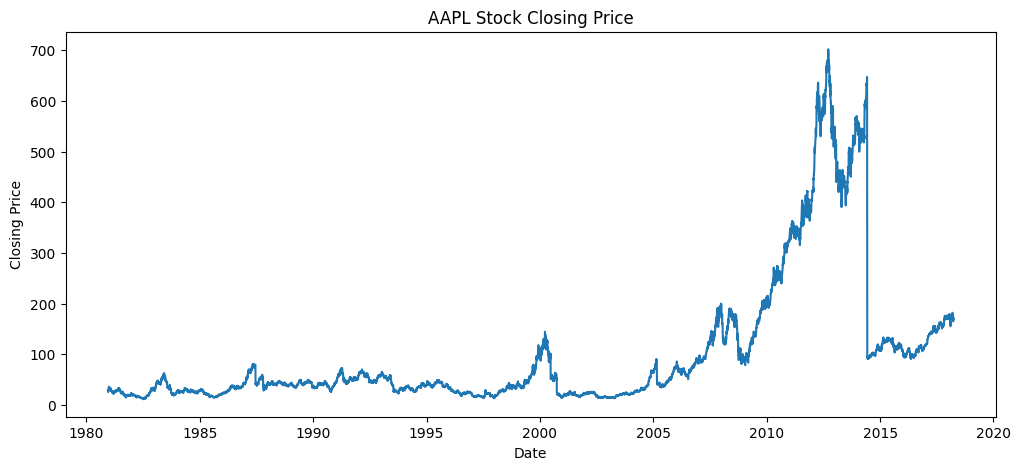

In [13]:
# Plot AAPL closing price
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(data["date"], data["close"])
plt.title("AAPL Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

In [14]:
# Normalize the closing prices
from sklearn.preprocessing import MinMaxScaler

prices = data[["close"]].dropna().values

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)

print("Number of prices:", len(prices))

Number of prices: 9400


In [15]:
# Create sequences using the previous 60 days
X = []
y = []

for i in range(60, len(scaled_prices)):
    X.append(scaled_prices[i-60:i, 0])
    y.append(scaled_prices[i, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape(X.shape[0], X.shape[1], 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9340, 60, 1)
y shape: (9340,)


In [16]:
# Split data into training and testing sets
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 7472
Testing samples: 1868


In [17]:
# Build the LSTM model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(60, 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Train the LSTM model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - loss: 3.3332e-04 - val_loss: 0.0022
Epoch 2/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 1.0834e-04 - val_loss: 0.0027
Epoch 3/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 1.1313e-04 - val_loss: 0.0018
Epoch 4/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 9.5046e-05 - val_loss: 0.0014
Epoch 5/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - loss: 8.8313e-05 - val_loss: 0.0016
Epoch 6/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - loss: 8.3171e-05 - val_loss: 0.0012
Epoch 7/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 7.6795e-05 - val_loss: 0.0012
Epoch 8/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 7.3092e-05 - val_loss: 0.0011
Epoch 9/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 7.5197e-05 - val_loss: 0.0011
Epoch 10/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 7.2704e-05 - val_loss: 0.0010
Epoch 11/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - loss: 7.4974e-05 - val_los

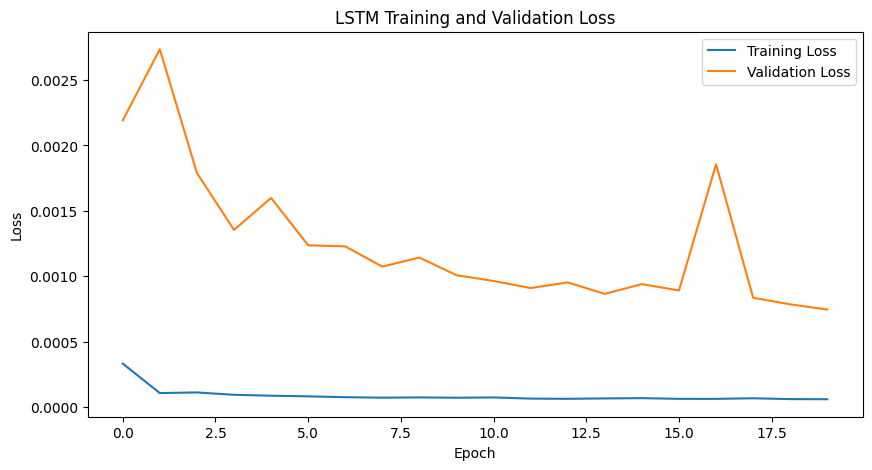

In [19]:
# Plot training and validation loss
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [20]:
# Generate predictions on the test data
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [21]:
# Evaluate the model using MAE and RMSE
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(actual, predictions)
rmse = np.sqrt(mean_squared_error(actual, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 5.890794357410897
RMSE: 18.881426413283187


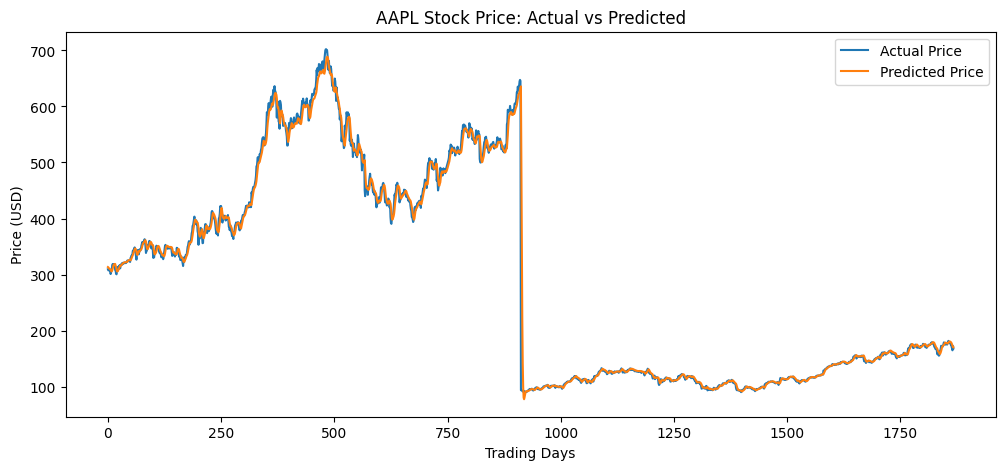

In [22]:
# Compare actual and predicted stock prices
plt.figure(figsize=(12,5))

plt.plot(actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")

plt.title("AAPL Stock Price: Actual vs Predicted")
plt.xlabel("Trading Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

In [23]:
# Predict the next closing price
last_60_days = scaled_prices[-60:]
last_60_days = last_60_days.reshape(1, 60, 1)

next_price = model.predict(last_60_days)
next_price = scaler.inverse_transform(next_price)

print("Predicted next closing price: $", round(float(next_price[0][0]), 2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted next closing price: $ 169.85
